# Submission Analysis

This notebook **auto-aggregates** all pipeline runs from `outputs/` and TTS samples from `results/`.

No external script needed — data is read directly from existing run artifacts.

In [4]:
from pathlib import Path
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "app").exists():
            return candidate
    return start

ROOT = find_project_root(Path.cwd())
OUTPUTS_DIR = ROOT / "outputs"
RESULTS_DIR = ROOT / "results"

print(f"Project root: {ROOT}")
print(f"Outputs dir:  {OUTPUTS_DIR}  (exists: {OUTPUTS_DIR.exists()})")
print(f"Results dir:  {RESULTS_DIR}  (exists: {RESULTS_DIR.exists()})")

Project root: c:\workspace\IITM\Jan--2026\fork\Group-4-DS-and-AI-Lab-Project
Outputs dir:  c:\workspace\IITM\Jan--2026\fork\Group-4-DS-and-AI-Lab-Project\outputs  (exists: True)
Results dir:  c:\workspace\IITM\Jan--2026\fork\Group-4-DS-and-AI-Lab-Project\results  (exists: True)


## 📋 Model Configuration

Auto-detected from `app/config/settings.py` and project file system.

In [5]:
def detect_model_config(root: Path) -> dict:
    info = {}

    yolo_rel = os.environ.get(
        "YOLO_WEIGHTS_REL",
        os.path.join("model_training", "object_detection", "best-weights", "YOLOv8n-uni.pt"),
    )
    yolo_path = root / yolo_rel
    info["yolo_architecture"] = "YOLOv8n (Ultralytics)"
    info["yolo_weights_file"] = yolo_path.name
    info["yolo_weights_path"] = str(yolo_path.relative_to(root)) if yolo_path.exists() else yolo_rel
    info["yolo_weights_exists"] = yolo_path.exists()
    info["yolo_weights_type"] = "Custom fine-tuned (YOLOv8n-uni)" if "uni" in yolo_path.name.lower() else "Pretrained"
    if yolo_path.exists():
        info["yolo_weights_size_mb"] = round(yolo_path.stat().st_size / (1024 * 1024), 1)

    depth_rel = os.environ.get(
        "DEPTH_MODEL_DIR_REL",
        os.path.join("model_training", "depth_estimation", "model_weights",
                     "depth_anything_v2_metric_hypersim_vits.pth"),
    )
    depth_path = root / depth_rel
    info["depth_architecture"] = "Depth-Anything-V2 (ViT-S, metric, hypersim)"
    info["depth_weights_file"] = depth_path.name
    info["depth_weights_path"] = str(depth_path.relative_to(root)) if depth_path.exists() else depth_rel
    info["depth_weights_exists"] = depth_path.exists()
    if depth_path.exists():
        info["depth_weights_size_mb"] = round(depth_path.stat().st_size / (1024 * 1024), 1)

    piper_voices_dir = root / "app" / "piper_voices"
    piper_onnx = list(piper_voices_dir.glob("*.onnx")) if piper_voices_dir.exists() else []
    if piper_onnx:
        voice = piper_onnx[0]
        info["tts_engine"] = "Piper TTS (ONNX, offline)"
        info["tts_voice_model"] = voice.name
        info["tts_voice_size_mb"] = round(voice.stat().st_size / (1024 * 1024), 1)
    else:
        info["tts_engine"] = "Piper TTS"
        info["tts_voice_model"] = "(not found in app/piper_voices/)"

    return info


model_config = detect_model_config(ROOT)

print("═" * 70)
print("  MODEL CONFIGURATION SUMMARY")
print("═" * 70)
print(f"  YOLO:  {model_config['yolo_architecture']}  →  {model_config['yolo_weights_file']}  ({model_config.get('yolo_weights_size_mb', '?')} MB, {model_config['yolo_weights_type']})")
print(f"  Depth: {model_config['depth_architecture']}  →  {model_config['depth_weights_file']}  ({model_config.get('depth_weights_size_mb', '?')} MB)")
print(f"  TTS:   {model_config['tts_engine']}  →  {model_config.get('tts_voice_model', 'N/A')}  ({model_config.get('tts_voice_size_mb', '?')} MB)")
print("═" * 70)

config_table = pd.DataFrame([
    {"Component": "Object Detection", "Architecture": model_config["yolo_architecture"],
     "Weights": model_config["yolo_weights_file"],
     "Size (MB)": model_config.get("yolo_weights_size_mb", "—"),
     "Type": model_config["yolo_weights_type"],
     "Path": model_config["yolo_weights_path"]},
    {"Component": "Depth Estimation", "Architecture": model_config["depth_architecture"],
     "Weights": model_config["depth_weights_file"],
     "Size (MB)": model_config.get("depth_weights_size_mb", "—"),
     "Type": "Pretrained (metric, HyperSim)",
     "Path": model_config["depth_weights_path"]},
    {"Component": "Text-to-Speech", "Architecture": model_config["tts_engine"],
     "Weights": model_config.get("tts_voice_model", "—"),
     "Size (MB)": model_config.get("tts_voice_size_mb", "—"),
     "Type": "Offline ONNX voice",
     "Path": "app/piper_voices/"},
])
display(config_table)

══════════════════════════════════════════════════════════════════════
  MODEL CONFIGURATION SUMMARY
══════════════════════════════════════════════════════════════════════
  YOLO:  YOLOv8n (Ultralytics)  →  YOLOv8n-uni.pt  (5.9 MB, Custom fine-tuned (YOLOv8n-uni))
  Depth: Depth-Anything-V2 (ViT-S, metric, hypersim)  →  depth_anything_v2_metric_hypersim_vits.pth  (94.6 MB)
  TTS:   Piper TTS (ONNX, offline)  →  en_US-amy-medium.onnx  (60.3 MB)
══════════════════════════════════════════════════════════════════════


,Component,Architecture,Weights,Size (MB),Type,Path
0,Object Detection,YOLOv8n (Ultralytics),YOLOv8n-uni.pt,5.9,Custom fine-tuned (YOLOv8n-uni),model_training\object_detection\best-weights\Y...
1,Depth Estimation,"Depth-Anything-V2 (ViT-S, metric, hypersim)",depth_anything_v2_metric_hypersim_vits.pth,94.6,"Pretrained (metric, HyperSim)",model_training\depth_estimation\model_weights\...
2,Text-to-Speech,"Piper TTS (ONNX, offline)",en_US-amy-medium.onnx,60.3,Offline ONNX voice,app/piper_voices/


## 🖥️ Hardware & Environment

Auto-detected machine specifications used for all benchmark runs.

In [6]:
import platform
import subprocess
import torch
import psutil

hw = {}

# ── OS & Python ─────────────────────────────────────────────────────
hw["OS"] = f"{platform.system()} {platform.release()} ({platform.version()})"
hw["Machine"] = platform.machine()
hw["Python"] = platform.python_version()

# ── CPU ──────────────────────────────────────────────────────────────
cpu_name = platform.processor() or "N/A"
if platform.system() == "Windows":
    try:
        result = subprocess.run(
            ["powershell", "-Command", "(Get-CimInstance Win32_Processor).Name"],
            capture_output=True, text=True, timeout=5
        )
        if result.returncode == 0 and result.stdout.strip():
            cpu_name = result.stdout.strip()
    except Exception:
        pass
hw["CPU"] = cpu_name
hw["CPU Cores (physical)"] = psutil.cpu_count(logical=False)
hw["CPU Cores (logical)"] = psutil.cpu_count(logical=True)

# ── RAM ──────────────────────────────────────────────────────────────
hw["RAM Total (GB)"] = round(psutil.virtual_memory().total / (1024**3), 1)
hw["RAM Available (GB)"] = round(psutil.virtual_memory().available / (1024**3), 1)

# ── GPU (PyTorch + CUDA) ────────────────────────────────────────────
hw["PyTorch"] = torch.__version__
hw["CUDA Available"] = torch.cuda.is_available()
if torch.cuda.is_available():
    hw["GPU"] = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    hw["GPU Memory (GB)"] = round(gpu_props.total_memory / (1024**3), 1)
    hw["CUDA Version"] = torch.version.cuda or "N/A"
    hw["cuDNN Version"] = str(torch.backends.cudnn.version()) if torch.backends.cudnn.is_available() else "N/A"
else:
    hw["GPU"] = "None (CPU only)"

# ── Display ────────────────────────────────────────────────────────
print("═" * 70)
print("  HARDWARE & ENVIRONMENT")
print("═" * 70)
for k, v in hw.items():
    print(f"  {k:.<30s} {v}")
print("═" * 70)

hw_df = pd.DataFrame(list(hw.items()), columns=["Property", "Value"])
display(hw_df)

══════════════════════════════════════════════════════════════════════
  HARDWARE & ENVIRONMENT
══════════════════════════════════════════════════════════════════════
  OS............................ Windows 10 (10.0.26200)
  Machine....................... AMD64
  Python........................ 3.11.14
  CPU........................... AMD64 Family 25 Model 117 Stepping 2, AuthenticAMD
  CPU Cores (physical).......... 8
  CPU Cores (logical)........... 16
  RAM Total (GB)................ 27.8
  RAM Available (GB)............ 12.0
  PyTorch....................... 2.5.1+cu121
  CUDA Available................ True
  GPU........................... NVIDIA GeForce RTX 4050 Laptop GPU
  GPU Memory (GB)............... 6.0
  CUDA Version.................. 12.1
  cuDNN Version................. 90100
══════════════════════════════════════════════════════════════════════


,Property,Value
0,OS,Windows 10 (10.0.26200)
1,Machine,AMD64
2,Python,3.11.14
3,CPU,"AMD64 Family 25 Model 117 Stepping 2, Authenti..."
4,CPU Cores (physical),8
5,CPU Cores (logical),16
6,RAM Total (GB),27.8
7,RAM Available (GB),12.0
8,PyTorch,2.5.1+cu121
9,CUDA Available,True


## 📋 Pipeline Execution Modes

From `app/config/pipeline_schema.py` — the pipeline supports two execution modes:
- **`sequential`** — components run one-by-one: YOLO → Depth → Fusion → Navigation → TTS
- **`threaded_parallel`** — YOLO and Depth run in parallel threads, then fuse

The benchmark runner (`app/runners/benchmark_runner.py`) tests **8 configurations**:

In [7]:
BENCHMARK_CONFIGS = [
    {"config": "detection_only",             "det": True,  "dep": False, "tts": False, "exec_mode": "sequential"},
    {"config": "depth_only",                 "det": False, "dep": True,  "tts": False, "exec_mode": "sequential"},
    {"config": "sequential_det_dep",          "det": True,  "dep": True,  "tts": False, "exec_mode": "sequential"},
    {"config": "parallel_det_dep",            "det": True,  "dep": True,  "tts": False, "exec_mode": "threaded_parallel"},
    {"config": "sequential_full_no_tts",      "det": True,  "dep": True,  "tts": False, "exec_mode": "sequential"},
    {"config": "sequential_full_with_tts",    "det": True,  "dep": True,  "tts": True,  "exec_mode": "sequential"},
    {"config": "parallel_full_no_tts",        "det": True,  "dep": True,  "tts": False, "exec_mode": "threaded_parallel"},
    {"config": "parallel_full_with_tts",      "det": True,  "dep": True,  "tts": True,  "exec_mode": "threaded_parallel"},
]

CONFIG_TO_MODE = {c["config"]: c["exec_mode"] for c in BENCHMARK_CONFIGS}
CONFIG_TO_COMPONENTS = {c["config"]: {"detection": c["det"], "depth": c["dep"], "tts": c["tts"]} for c in BENCHMARK_CONFIGS}

print("Pipeline Benchmark Configuration Matrix")
print("=" * 70)
bc_df = pd.DataFrame(BENCHMARK_CONFIGS)
bc_df.columns = ["Config Name", "Detection", "Depth", "TTS", "Execution Mode"]
display(bc_df)

Pipeline Benchmark Configuration Matrix


,Config Name,Detection,Depth,TTS,Execution Mode
0,detection_only,True,False,False,sequential
1,depth_only,False,True,False,sequential
2,sequential_det_dep,True,True,False,sequential
3,parallel_det_dep,True,True,False,threaded_parallel
4,sequential_full_no_tts,True,True,False,sequential
5,sequential_full_with_tts,True,True,True,sequential
6,parallel_full_no_tts,True,True,False,threaded_parallel
7,parallel_full_with_tts,True,True,True,threaded_parallel


## 1) Auto-Aggregate All Pipeline Runs from `outputs/`

Scans every subdirectory under `outputs/` for:
- `latency_summary.csv` + `run_summary.json` → individual bench/eval/live runs
- `benchmark_comparison.csv` → benchmark suite runs (multiple configs tested)

**Execution mode** is derived from config name for all run types.  
**Disabled-component latencies are forced to NaN** (not 0).

In [9]:
def infer_execution_mode(config_name: str) -> str:
    if config_name in CONFIG_TO_MODE:
        return CONFIG_TO_MODE[config_name]
    if "parallel" in config_name.lower():
        return "threaded_parallel"
    return "sequential"


def infer_components(config_name: str) -> dict:
    if config_name in CONFIG_TO_COMPONENTS:
        return CONFIG_TO_COMPONENTS[config_name]
    c = config_name.lower()
    return {
        "detection": "detection" in c or "det" in c or "full" in c or "eval" in c or "live" in c,
        "depth": "depth" in c or "dep" in c or "full" in c or "eval" in c or "live" in c,
        "tts": "tts" in c and "no_tts" not in c,
    }


def aggregate_pipeline_runs(outputs_dir: Path) -> pd.DataFrame:
    records = []

    for run_dir in sorted(outputs_dir.iterdir()):
        if not run_dir.is_dir():
            continue

        name = run_dir.name
        latency_csv = run_dir / "latency_summary.csv"
        run_json = run_dir / "run_summary.json"
        bench_comparison_csv = run_dir / "benchmark_comparison.csv"

        if name.startswith("benchmark_"):
            run_type = "benchmark_suite"
        elif name.startswith("bench_"):
            run_type = "benchmark"
        elif name.startswith("dataset_eval_"):
            run_type = "dataset_eval"
        elif name.startswith("live_run_"):
            run_type = "live"
        else:
            run_type = "other"

        if run_type == "benchmark_suite" and bench_comparison_csv.exists():
            try:
                bdf = pd.read_csv(bench_comparison_csv)
                for _, br in bdf.iterrows():
                    cfg = str(br.get("config_name", ""))
                    comps = infer_components(cfg)
                    records.append({
                        "run_name": name,
                        "run_type": run_type,
                        "config": cfg,
                        "execution_mode": br.get("execution_mode", infer_execution_mode(cfg)),
                        "detection": comps["detection"],
                        "depth": comps["depth"],
                        "tts": comps["tts"],
                        "total_frames": br.get("total_frames"),
                        "duration_s": round(float(br.get("total_runtime_sec", 0)), 1),
                        "avg_fps_instant": br.get("avg_fps"),
                        "avg_loop_total_latency_ms": br.get("avg_frame_latency_ms"),
                        "avg_yolo_latency_ms": br.get("avg_yolo_latency_ms") if comps["detection"] else np.nan,
                        "avg_depth_latency_ms": br.get("avg_depth_latency_ms") if comps["depth"] else np.nan,
                        "avg_tts_latency_ms": br.get("avg_tts_latency_ms") if comps["tts"] else np.nan,
                        "p95_loop_total_latency_ms": br.get("p95_frame_latency_ms"),
                        "has_frame_metrics": False,
                        "has_video": False,
                    })
            except Exception as e:
                records.append({"run_name": name, "run_type": run_type, "config": name,
                                "execution_mode": "—", "_error": str(e)})
            continue

        row = {"run_name": name, "run_type": run_type}

        parts = name.split("_")
        if name.startswith("bench_") and len(parts) >= 4:
            cfg = "_".join(parts[1:-2])
        else:
            cfg = name
        row["config"] = cfg

        row["execution_mode"] = infer_execution_mode(cfg)
        comps = infer_components(cfg)
        row["detection"] = comps["detection"]
        row["depth"] = comps["depth"]
        row["tts"] = comps["tts"]

        if run_type in ("dataset_eval", "live"):
            row["detection"] = True
            row["depth"] = True
            row["tts"] = True
            row["execution_mode"] = "sequential"

        if run_json.exists():
            try:
                rs = json.loads(run_json.read_text(encoding="utf-8"))
                row["total_frames"] = rs.get("total_frames")
                row["duration_s"] = round(rs.get("duration_seconds", 0), 1)
            except Exception:
                pass

        if latency_csv.exists():
            try:
                ldf = pd.read_csv(latency_csv)
                if not ldf.empty:
                    lr = ldf.iloc[0]
                    for col in ["avg_fps_instant", "avg_loop_total_latency_ms",
                                "avg_yolo_latency_ms", "avg_depth_latency_ms",
                                "avg_tts_latency_ms", "avg_navigation_latency_ms",
                                "avg_fusion_latency_ms", "avg_visualization_latency_ms",
                                "avg_frame_total_latency_ms",
                                "p95_loop_total_latency_ms", "p95_frame_total_latency_ms",
                                "median_fps_instant", "median_loop_total_latency_ms"]:
                        if col in lr.index:
                            row[col] = lr[col]
            except Exception:
                pass

        row["has_frame_metrics"] = (run_dir / "frame_metrics.csv").exists()
        row["has_video"] = (run_dir / "annotated_video.mp4").exists()

        records.append(row)

    return pd.DataFrame(records)


df = aggregate_pipeline_runs(OUTPUTS_DIR)

# ── Cleanup: Force NaN for disabled-component latencies ─────────────
if "tts" in df.columns and "avg_tts_latency_ms" in df.columns:
    df.loc[df["tts"] == False, "avg_tts_latency_ms"] = np.nan
if "detection" in df.columns and "avg_yolo_latency_ms" in df.columns:
    df.loc[df["detection"] == False, "avg_yolo_latency_ms"] = np.nan
if "depth" in df.columns and "avg_depth_latency_ms" in df.columns:
    df.loc[df["depth"] == False, "avg_depth_latency_ms"] = np.nan

print(f"Found {len(df)} entries from outputs/")
print(f"\nRun types: {df['run_type'].value_counts().to_dict()}")
print(f"Execution modes: {df['execution_mode'].value_counts().to_dict()}")
df.head(60)

Found 55 entries from outputs/

Run types: {'benchmark': 24, 'benchmark_suite': 24, 'live': 5, 'dataset_eval': 2}
Execution modes: {'sequential': 37, 'threaded_parallel': 18}


,run_name,run_type,config,execution_mode,detection,depth,tts,total_frames,duration_s,avg_fps_instant,...,avg_navigation_latency_ms,avg_fusion_latency_ms,avg_visualization_latency_ms,avg_frame_total_latency_ms,p95_loop_total_latency_ms,p95_frame_total_latency_ms,median_fps_instant,median_loop_total_latency_ms,has_frame_metrics,has_video
0,bench_depth_only_20260406_101723,benchmark,depth_only,sequential,False,True,False,100,163.9,0.621968,...,0.051089,0.010017,5.709750,1559.498747,1758.143225,1672.363110,0.600118,1666.33905,True,False
1,bench_depth_only_20260408_204249,benchmark,depth_only,sequential,False,True,False,100,136.9,0.736612,...,0.046078,0.008946,4.696347,1288.067806,1478.578780,1394.450550,0.732330,1365.50410,True,True
2,bench_depth_only_20260408_212937,benchmark,depth_only,sequential,False,True,False,300,383.8,0.783418,...,0.047061,0.009077,4.252241,1253.856929,1372.037990,1342.497610,0.785661,1272.81395,True,True
3,bench_detection_only_20260406_101713,benchmark,detection_only,sequential,True,False,False,100,9.9,11.429992,...,0.047816,0.005944,5.423223,39.726356,100.280010,44.968300,11.241639,88.95500,True,False
4,bench_detection_only_20260408_204239,benchmark,detection_only,sequential,True,False,False,100,9.2,11.965143,...,0.039454,0.005039,3.758656,29.772049,102.807510,37.559105,12.019195,83.20025,True,True
5,bench_detection_only_20260408_212923,benchmark,detection_only,sequential,True,False,False,300,14.3,21.585342,...,0.038418,0.004427,3.574014,29.163998,55.103015,34.567430,21.554442,46.39415,True,True
6,bench_parallel_det_dep_20260406_102315,benchmark,parallel_det_dep,threaded_parallel,True,True,False,100,179.9,0.563571,...,0.077808,7.308615,6.535198,1707.459373,1941.146515,1860.410160,0.566717,1764.55070,True,False
7,bench_parallel_det_dep_20260408_204730,benchmark,parallel_det_dep,threaded_parallel,True,True,False,100,143.5,0.701765,...,0.067368,5.400227,5.163469,1354.494753,1523.932710,1447.022430,0.707271,1413.88605,True,True
8,bench_parallel_det_dep_20260408_214250,benchmark,parallel_det_dep,threaded_parallel,True,True,False,300,425.9,0.717389,...,0.070110,3.941782,5.584908,1389.377105,1748.544900,1710.690850,0.694092,1440.73100,True,True
9,bench_parallel_full_no_tts_20260406_103213,benchmark,parallel_full_no_tts,threaded_parallel,True,True,False,100,167.9,0.600871,...,0.071285,6.926684,6.554179,1596.439527,1727.201630,1658.150740,0.601516,1662.46540,True,False


## 2) Benchmark Runs — FPS & Latency Comparison

Combines both individual `bench_*` runs **and** configs from `benchmark_*` suites.

Benchmark configs (latest per config): 8


,config,execution_mode,detection,depth,tts,total_frames,duration_s,avg_fps_instant,avg_loop_total_latency_ms,avg_yolo_latency_ms,avg_depth_latency_ms,avg_tts_latency_ms
1,detection_only,sequential,True,False,False,300,14.4,21.59,29.16,25.53,NaN,NaN
0,depth_only,sequential,False,True,False,300,383.9,0.78,1253.86,NaN,1249.52,NaN
5,sequential_det_dep,sequential,True,True,False,300,409.6,0.74,1336.52,36.51,1291.29,NaN
2,parallel_det_dep,threaded_parallel,True,True,False,300,426.0,0.72,1389.38,59.53,1378.30,NaN
4,parallel_full_with_tts,threaded_parallel,True,True,True,300,464.3,0.65,1510.32,67.62,1498.36,0.01
6,sequential_full_no_tts,sequential,True,True,False,300,462.2,0.65,1503.63,46.39,1446.25,NaN
7,sequential_full_with_tts,sequential,True,True,True,300,463.9,0.65,1508.70,45.99,1451.19,0.01
3,parallel_full_no_tts,threaded_parallel,True,True,False,300,478.5,0.63,1562.93,68.04,1550.73,NaN


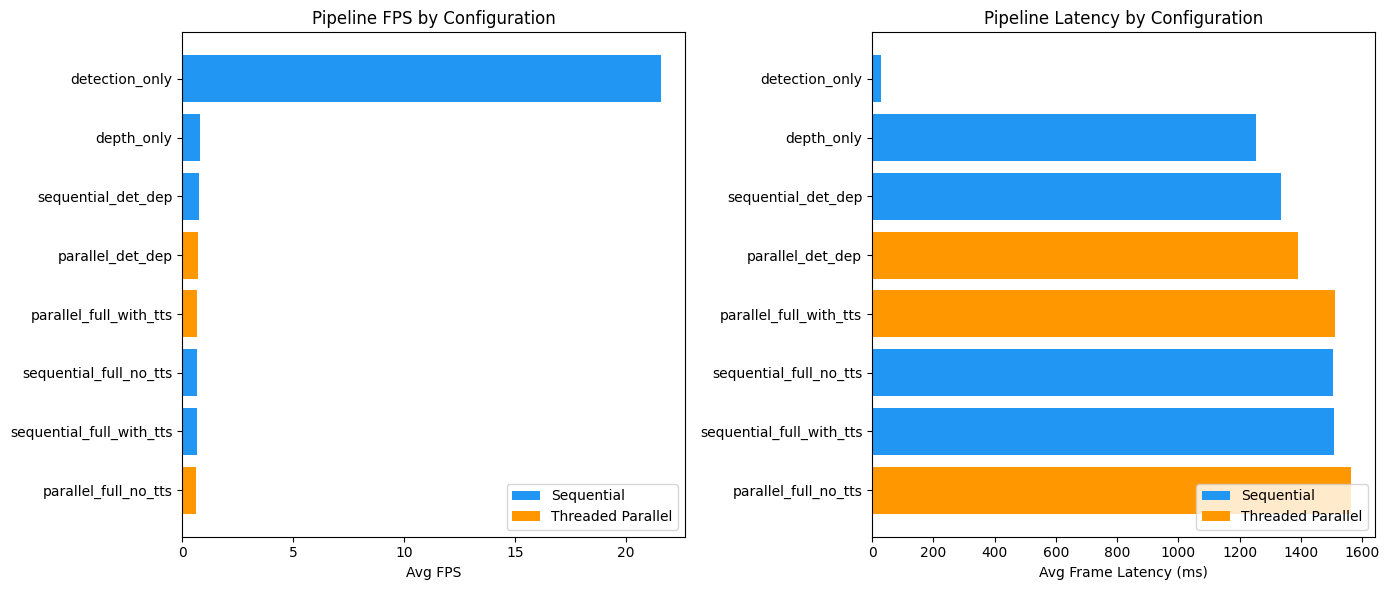

In [10]:
bench_df = df[df["run_type"].isin(["benchmark", "benchmark_suite"])].copy()

if bench_df.empty:
    print("No benchmark runs found.")
else:
    bench_latest = bench_df.sort_values("run_name").groupby("config").last().reset_index()
    bench_latest = bench_latest.sort_values("avg_fps_instant", ascending=False)

    cols_to_show = ["config", "execution_mode", "detection", "depth", "tts",
                    "total_frames", "duration_s",
                    "avg_fps_instant", "avg_loop_total_latency_ms",
                    "avg_yolo_latency_ms", "avg_depth_latency_ms", "avg_tts_latency_ms"]
    cols_available = [c for c in cols_to_show if c in bench_latest.columns]

    print(f"Benchmark configs (latest per config): {len(bench_latest)}")
    display(bench_latest[cols_available].round(2))

    plot_df = bench_latest.dropna(subset=["avg_fps_instant"])

    if not plot_df.empty:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        mode_colors = {"sequential": "#2196F3", "threaded_parallel": "#FF9800"}
        bar_colors = [mode_colors.get(m, "gray") for m in plot_df["execution_mode"]]

        ax = axes[0]
        ax.barh(plot_df["config"], plot_df["avg_fps_instant"], color=bar_colors)
        ax.set_xlabel("Avg FPS")
        ax.set_title("Pipeline FPS by Configuration")
        ax.invert_yaxis()
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='#2196F3', label='Sequential'),
                           Patch(facecolor='#FF9800', label='Threaded Parallel')]
        ax.legend(handles=legend_elements, loc='lower right')

        ax = axes[1]
        ax.barh(plot_df["config"], plot_df["avg_loop_total_latency_ms"], color=bar_colors)
        ax.set_xlabel("Avg Frame Latency (ms)")
        ax.set_title("Pipeline Latency by Configuration")
        ax.invert_yaxis()
        ax.legend(handles=legend_elements, loc='lower right')

        plt.tight_layout()
        plt.show()

## 3) Sequential vs Parallel — Direct Comparison

In [11]:
if bench_df.empty:
    print("No benchmark data.")
else:
    pairs = [
        ("sequential_det_dep", "parallel_det_dep", "Det + Depth"),
        ("sequential_full_no_tts", "parallel_full_no_tts", "Full (no TTS)"),
        ("sequential_full_with_tts", "parallel_full_with_tts", "Full (with TTS)"),
    ]

    comparison_rows = []
    for seq_cfg, par_cfg, label in pairs:
        seq_row = bench_latest[bench_latest["config"] == seq_cfg]
        par_row = bench_latest[bench_latest["config"] == par_cfg]
        if not seq_row.empty and not par_row.empty:
            s = seq_row.iloc[0]
            p = par_row.iloc[0]
            comparison_rows.append({
                "Components": label,
                "Seq FPS": round(s.get("avg_fps_instant", 0), 2),
                "Par FPS": round(p.get("avg_fps_instant", 0), 2),
                "Seq Latency (ms)": round(s.get("avg_loop_total_latency_ms", 0), 1),
                "Par Latency (ms)": round(p.get("avg_loop_total_latency_ms", 0), 1),
                "FPS Δ%": round((p.get("avg_fps_instant", 0) / s.get("avg_fps_instant", 1) - 1) * 100, 1),
                "Latency Δ%": round((p.get("avg_loop_total_latency_ms", 0) / s.get("avg_loop_total_latency_ms", 1) - 1) * 100, 1),
            })

    if comparison_rows:
        comp_df = pd.DataFrame(comparison_rows)
        print("Sequential vs Threaded Parallel — Direct Comparison")
        print("=" * 60)
        display(comp_df)
        print("\n+ FPS Δ% = parallel is faster  |  - Latency Δ% = parallel is lower latency")
    else:
        print("No matching sequential/parallel pairs found.")

Sequential vs Threaded Parallel — Direct Comparison


,Components,Seq FPS,Par FPS,Seq Latency (ms),Par Latency (ms),FPS Δ%,Latency Δ%
0,Det + Depth,0.74,0.72,1336.5,1389.4,-2.7,4.0
1,Full (no TTS),0.65,0.63,1503.6,1562.9,-2.7,3.9
2,Full (with TTS),0.65,0.65,1508.7,1510.3,0.5,0.1



+ FPS Δ% = parallel is faster  |  - Latency Δ% = parallel is lower latency


## 4) Benchmark Suite — Stacked Latency Breakdown

Found 3 benchmark_comparison.csv files:
  outputs\benchmark_20260406_101713\benchmark_comparison.csv
  outputs\benchmark_20260408_204239\benchmark_comparison.csv
  outputs\benchmark_20260408_212923\benchmark_comparison.csv

Latest benchmark suite (benchmark_20260408_212923):


,avg_depth_latency_ms,avg_fps,avg_frame_latency_ms,avg_tts_latency_ms,avg_yolo_latency_ms,config_name,execution_mode,p95_frame_latency_ms,total_frames,total_runtime_sec
0,NaN,21.585342,29.163998,NaN,25.527553,detection_only,sequential,34.567430,300,14.374516
1,1249.517892,0.783418,1253.856929,NaN,NaN,depth_only,sequential,1342.497610,300,383.922055
2,1291.285110,0.737474,1336.521144,NaN,36.507272,sequential_det_dep,sequential,1481.132930,300,409.589574
3,1378.297382,0.717389,1389.377105,NaN,59.526713,parallel_det_dep,threaded_parallel,1710.690850,300,425.978966
4,1498.359524,0.652548,1510.322863,0.013515,67.616647,parallel_full_with_tts,threaded_parallel,1738.057560,300,464.330300
5,1446.252080,0.651673,1503.632476,NaN,46.390321,sequential_full_no_tts,sequential,1646.905005,300,462.164990
6,1451.191665,0.649581,1508.698479,0.014366,45.987511,sequential_full_with_tts,sequential,1627.478810,300,463.856287
7,1550.731731,0.633790,1562.929235,NaN,68.039500,parallel_full_no_tts,threaded_parallel,1818.123995,300,478.468907


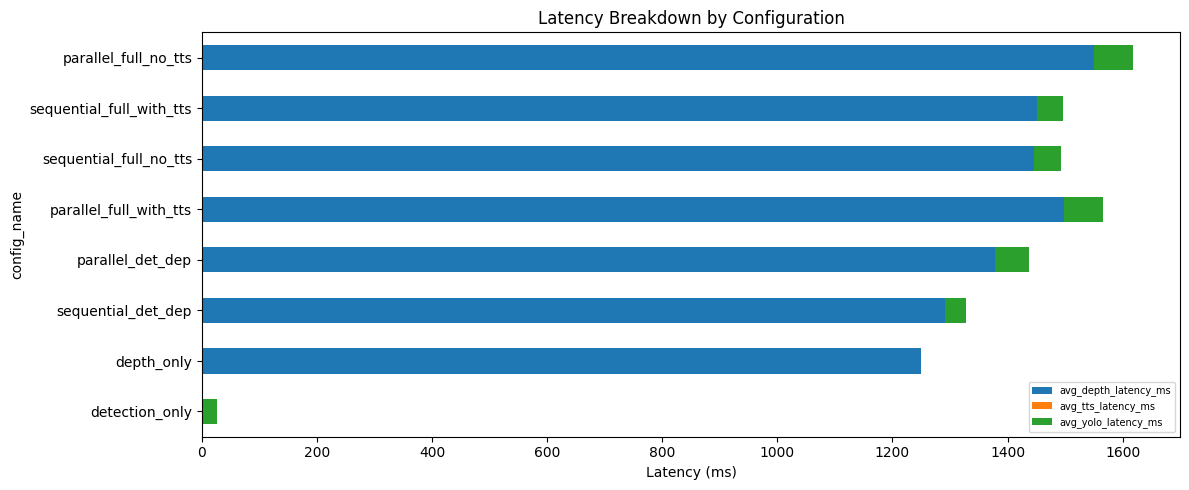

In [12]:
bench_csvs = sorted(OUTPUTS_DIR.glob("benchmark_*/benchmark_comparison.csv"))
print(f"Found {len(bench_csvs)} benchmark_comparison.csv files:")
for p in bench_csvs:
    print(f"  {p.relative_to(ROOT)}")

if bench_csvs:
    bdf = pd.read_csv(bench_csvs[-1])
    bdf = bdf.sort_values("avg_fps", ascending=False).reset_index(drop=True)
    print(f"\nLatest benchmark suite ({bench_csvs[-1].parent.name}):")
    display(bdf)

    latency_cols = [c for c in bdf.columns if c.startswith("avg_") and c.endswith("_ms") and c != "avg_frame_latency_ms"]
    if latency_cols:
        fig, ax = plt.subplots(figsize=(12, 5))
        bdf_plot = bdf.set_index("config_name")[latency_cols].fillna(0)
        bdf_plot.plot(kind="barh", stacked=True, ax=ax)
        ax.set_xlabel("Latency (ms)")
        ax.set_title("Latency Breakdown by Configuration")
        ax.legend(fontsize=7, loc="lower right")
        plt.tight_layout()
        plt.show()
else:
    print("No benchmark suite results found.")

## 5) Dataset Evaluation Runs

In [13]:
eval_df = df[df["run_type"] == "dataset_eval"].copy()

if eval_df.empty:
    print("No dataset_eval runs found.")
else:
    eval_cols = ["run_name", "execution_mode", "total_frames", "duration_s",
                 "avg_fps_instant", "avg_loop_total_latency_ms",
                 "avg_yolo_latency_ms", "avg_depth_latency_ms",
                 "avg_tts_latency_ms", "avg_navigation_latency_ms"]
    eval_cols = [c for c in eval_cols if c in eval_df.columns]

    print(f"Dataset evaluation runs: {len(eval_df)}")
    display(eval_df[eval_cols].round(2))

    latest_eval = eval_df.sort_values("run_name").iloc[-1]
    frame_csv = OUTPUTS_DIR / latest_eval["run_name"] / "frame_metrics.csv"

    if frame_csv.exists():
        fdf = pd.read_csv(frame_csv)
        print(f"\nLatest eval: {latest_eval['run_name']} ({len(fdf)} frames)")

        lat_cols = [c for c in fdf.columns if "latency" in c.lower() or "fps" in c.lower()]
        if lat_cols:
            stats = fdf[lat_cols].describe().T[["mean", "50%", "std", "max"]]
            stats.columns = ["avg", "median", "std", "max"]
            display(stats.round(2))

Dataset evaluation runs: 2


,run_name,execution_mode,total_frames,duration_s,avg_fps_instant,avg_loop_total_latency_ms,avg_yolo_latency_ms,avg_depth_latency_ms,avg_tts_latency_ms,avg_navigation_latency_ms
48,dataset_eval_20260408_200832,sequential,172,242.9,0.72,1403.24,39.40,1310.98,0.01,0.07
49,dataset_eval_20260415_235611,sequential,376,197.7,3.22,515.11,42.65,390.20,0.02,0.12



Latest eval: dataset_eval_20260415_235611 (376 frames)


,avg,median,std,max
decision_latency_ms,0.09,0.05,0.29,3.34
depth_latency_ms,390.20,209.08,612.82,8668.88
display_latency_ms,0.00,0.00,0.00,0.00
fps_instant,3.22,3.70,1.26,5.01
frame_total_latency_ms,457.14,237.23,833.24,12853.09
fusion_latency_ms,14.23,3.96,84.59,1030.02
loop_total_latency_ms,515.11,270.45,941.11,13909.06
navigation_latency_ms,0.12,0.07,0.36,4.23
tts_latency_ms,0.02,0.01,0.04,0.36
visualization_latency_ms,9.87,4.68,42.84,454.90


## 6) TTS Samples Analysis

In [14]:
tts_csvs = sorted(RESULTS_DIR.glob("tts_samples_*/tts_samples_metrics.csv"))
print(f"Found {len(tts_csvs)} TTS sample metric files:")
for p in tts_csvs:
    print(f"  {p.relative_to(ROOT)}")

if tts_csvs:
    tts = pd.read_csv(tts_csvs[-1])
    print(f"\nLatest TTS samples ({tts_csvs[-1].parent.name}):")
    display(tts[["idx", "text", "synth_ms", "duration_s", "rtf"]].round(4))

    print(f"\nRTF Summary:")
    print(f"  Avg RTF:    {tts['rtf'].mean():.4f}")
    print(f"  Max RTF:    {tts['rtf'].max():.4f}")
    print(f"  Min RTF:    {tts['rtf'].min():.4f}")
    print(f"  All < 1.0:  {(tts['rtf'] < 1.0).all()}")
else:
    tts = None
    print("No TTS samples found.")

Found 1 TTS sample metric files:
  results\tts_samples_2026-04-15\tts_samples_metrics.csv

Latest TTS samples (tts_samples_2026-04-15):


,idx,text,synth_ms,duration_s,rtf
0,1,Stop. Obstacle ahead.,748.8052,2.3737,0.3155
1,2,Clear path on your left. Turn left.,1346.7131,3.4650,0.3887
2,3,Clear path on your right. Turn right.,1115.7016,3.0703,0.3634
3,4,Proceed forward. Path is clear.,834.6918,2.9310,0.2848
4,5,Caution. Obstacle near the center.,741.0402,2.9078,0.2548
5,6,Turn back. Path ahead is blocked.,922.3458,3.2677,0.2823



RTF Summary:
  Avg RTF:    0.3149
  Max RTF:    0.3887
  Min RTF:    0.2548
  All < 1.0:  True


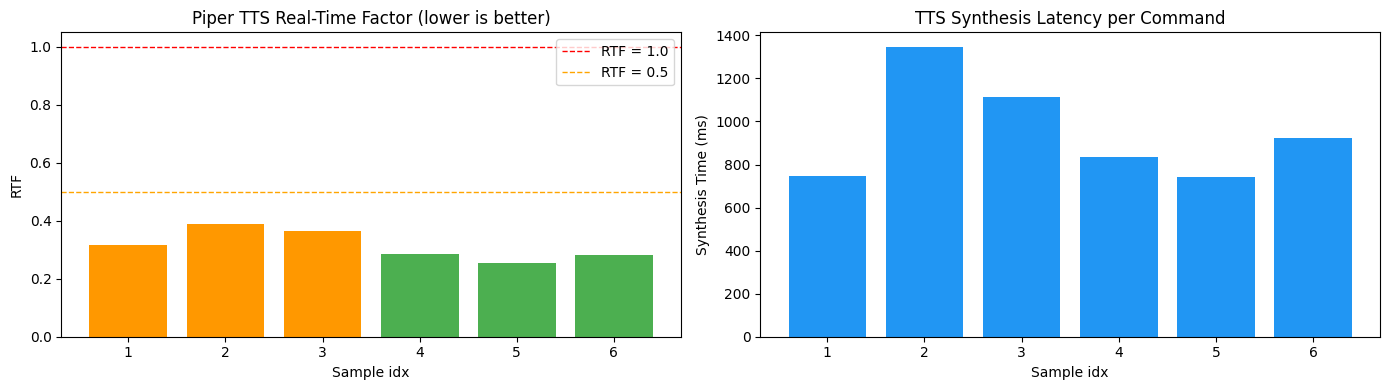

In [15]:
if tts is not None and not tts.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    colors_rtf = ["#4CAF50" if r < 0.3 else "#FF9800" if r < 0.5 else "#F44336" for r in tts["rtf"]]
    ax.bar(tts["idx"], tts["rtf"], color=colors_rtf)
    ax.axhline(1.0, linestyle="--", color="red", linewidth=1, label="RTF = 1.0")
    ax.axhline(0.5, linestyle="--", color="orange", linewidth=1, label="RTF = 0.5")
    ax.set_xlabel("Sample idx")
    ax.set_ylabel("RTF")
    ax.set_title("Piper TTS Real-Time Factor (lower is better)")
    ax.legend()

    ax = axes[1]
    ax.bar(tts["idx"], tts["synth_ms"], color="#2196F3")
    ax.set_xlabel("Sample idx")
    ax.set_ylabel("Synthesis Time (ms)")
    ax.set_title("TTS Synthesis Latency per Command")

    plt.tight_layout()
    plt.show()
else:
    print("No TTS data to plot.")

## 7) TTS RTF Evaluation Results (from `results/tts_eval/`)

In [16]:
tts_eval_dir = RESULTS_DIR / "tts_eval"

rtf_csvs = sorted(tts_eval_dir.glob("rtf_bench_*_dataset_summary.csv"))
rtf_reports = sorted(tts_eval_dir.glob("rtf_bench_*_report.json"))

print(f"TTS RTF benchmark results: {len(rtf_csvs)} summary CSVs, {len(rtf_reports)} report JSONs")

if rtf_reports:
    latest_report = json.loads(rtf_reports[-1].read_text(encoding="utf-8"))
    print(f"\nLatest RTF benchmark report ({rtf_reports[-1].name}):")
    for k, v in latest_report.items():
        if k != "hardware":
            print(f"  {k}: {v}")

if rtf_csvs:
    rtf_summary = pd.read_csv(rtf_csvs[-1])
    print(f"\nDataset breakdown:")
    display(rtf_summary)
elif not rtf_csvs:
    print("\nNo RTF benchmark results yet. Run notebooks/06_tts_rtf_benchmarking.ipynb first.")

TTS RTF benchmark results: 0 summary CSVs, 0 report JSONs

No RTF benchmark results yet. Run notebooks/06_tts_rtf_benchmarking.ipynb first.


## 8) Full Summary Table — All Runs

In [17]:
summary_cols = ["run_name", "run_type", "config", "execution_mode",
                "detection", "depth", "tts",
                "total_frames", "duration_s",
                "avg_fps_instant", "avg_loop_total_latency_ms",
                "avg_yolo_latency_ms", "avg_depth_latency_ms", "avg_tts_latency_ms",
                "has_frame_metrics", "has_video"]
available_cols = [c for c in summary_cols if c in df.columns]

print(f"Complete pipeline runs inventory: {len(df)} entries")
display(df[available_cols].round(2))

summary_out = RESULTS_DIR / "pipeline_runs_summary.csv"
df.to_csv(summary_out, index=False, encoding="utf-8")
print(f"\n✅ Aggregated summary saved → {summary_out.relative_to(ROOT)}")

Complete pipeline runs inventory: 55 entries


,run_name,run_type,config,execution_mode,detection,depth,tts,total_frames,duration_s,avg_fps_instant,avg_loop_total_latency_ms,avg_yolo_latency_ms,avg_depth_latency_ms,avg_tts_latency_ms,has_frame_metrics,has_video
0,bench_depth_only_20260406_101723,benchmark,depth_only,sequential,False,True,False,100,163.9,0.62,1628.75,NaN,1553.69,NaN,True,False
1,bench_depth_only_20260408_204249,benchmark,depth_only,sequential,False,True,False,100,136.9,0.74,1363.10,NaN,1283.28,NaN,True,True
2,bench_depth_only_20260408_212937,benchmark,depth_only,sequential,False,True,False,300,383.8,0.78,1278.91,NaN,1249.52,NaN,True,True
3,bench_detection_only_20260406_101713,benchmark,detection_only,sequential,True,False,False,100,9.9,11.43,88.92,34.23,NaN,NaN,True,False
4,bench_detection_only_20260408_204239,benchmark,detection_only,sequential,True,False,False,100,9.2,11.97,84.73,25.95,NaN,NaN,True,True
5,bench_detection_only_20260408_212923,benchmark,detection_only,sequential,True,False,False,300,14.3,21.59,47.06,25.53,NaN,NaN,True,True
6,bench_parallel_det_dep_20260406_102315,benchmark,parallel_det_dep,threaded_parallel,True,True,False,100,179.9,0.56,1778.29,67.48,1692.00,NaN,True,False
7,bench_parallel_det_dep_20260408_204730,benchmark,parallel_det_dep,threaded_parallel,True,True,False,100,143.5,0.70,1426.99,44.79,1342.58,NaN,True,True
8,bench_parallel_det_dep_20260408_214250,benchmark,parallel_det_dep,threaded_parallel,True,True,False,300,425.9,0.72,1418.87,59.53,1378.30,NaN,True,True
9,bench_parallel_full_no_tts_20260406_103213,benchmark,parallel_full_no_tts,threaded_parallel,True,True,False,100,167.9,0.60,1665.44,59.52,1581.43,NaN,True,False



✅ Aggregated summary saved → results\pipeline_runs_summary.csv
